In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
titanic_url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(titanic_url)
features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']
titanic_df = titanic_df[features + ['Survived']].copy()

titanic_df['Age'] = titanic_df['Age'].fillna(titanic_df['Age'].median())
titanic_df['Embarked'] = titanic_df['Embarked'].fillna(titanic_df['Embarked'].mode()[0])

titanic_df = pd.get_dummies(titanic_df, columns=['Sex', 'Embarked'], drop_first=True)

X = titanic_df.drop('Survived', axis=1)
y = titanic_df['Survived']

print("Titanic Dataset Shape:", titanic_df.shape)
print("\nClass Distribution:")
print(y.value_counts())


Titanic Dataset Shape: (891, 9)

Class Distribution:
Survived
0    549
1    342
Name: count, dtype: int64


In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score

model = RandomForestClassifier(random_state=42)

cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

cv_scores = cross_val_score(
    model, X, y, cv=cv, scoring='accuracy'
)

print("10-Fold CV Accuracy Scores:")
print(cv_scores.round(4))

print(f"\nMean CV Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Standard Deviation: {cv_scores.std()*100:.2f}%")


10-Fold CV Accuracy Scores:
[0.8333 0.809  0.7978 0.8315 0.7865 0.8539 0.8427 0.809  0.8202 0.8427]

Mean CV Accuracy: 82.27%
Standard Deviation: 2.07%


In [3]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X, y)

print("Best Parameters:")
print(grid_search.best_params_)

print(f"\nBest Cross-Validation Accuracy: {grid_search.best_score_*100:.2f}%")


Best Parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 150}

Best Cross-Validation Accuracy: 83.39%


10-Fold CV Accuracy Scores:
[0.8333 0.809  0.7978 0.8315 0.7865 0.8539 0.8427 0.809  0.8202 0.8427]

Mean CV Accuracy: 82.27%
Standard Deviation: 2.07%


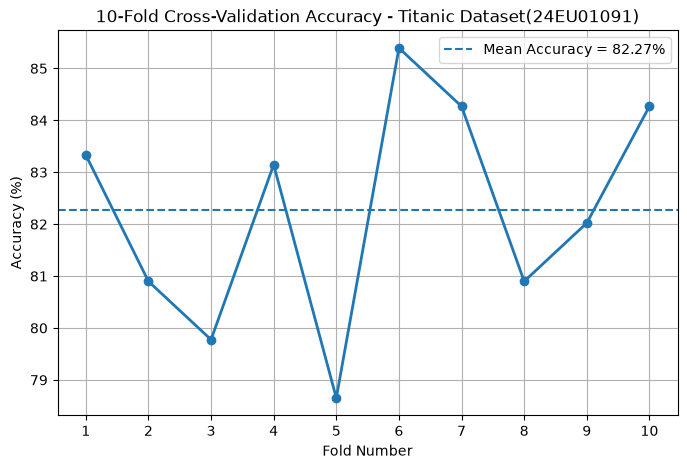

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
model = RandomForestClassifier(random_state=42)
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    model, X, y, cv=cv, scoring='accuracy'
)

print("10-Fold CV Accuracy Scores:")
print(cv_scores.round(4))
print(f"\nMean CV Accuracy: {cv_scores.mean()*100:.2f}%")
print(f"Standard Deviation: {cv_scores.std()*100:.2f}%")
folds = range(1, 11)


plt.figure(figsize=(8, 5))
plt.plot(folds, cv_scores * 100, marker='o', linewidth=2)
plt.axhline(
    cv_scores.mean() * 100,
    linestyle='--',
    label=f'Mean Accuracy = {cv_scores.mean()*100:.2f}%'
)


plt.xlabel('Fold Number')
plt.ylabel('Accuracy (%)')
plt.title('10-Fold Cross-Validation Accuracy - Titanic Dataset(24EU01091)')
plt.xticks(folds)
plt.grid(True)
plt.legend()
plt.show()

